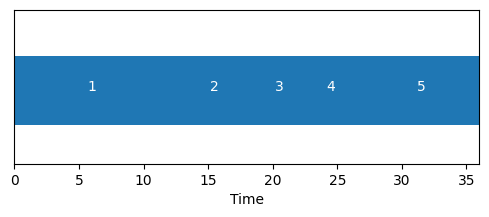

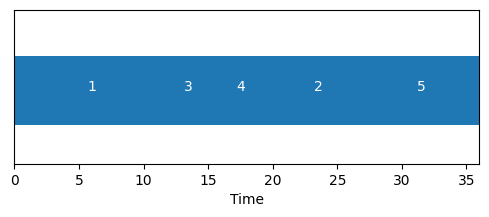

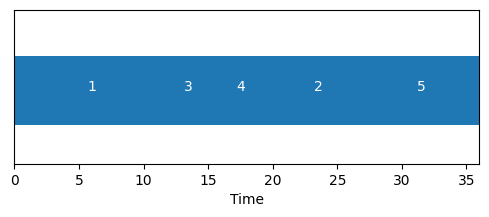

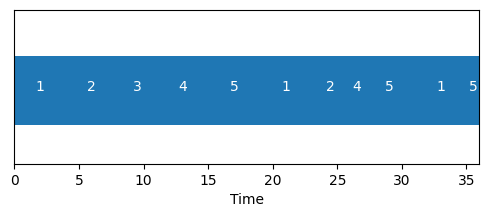

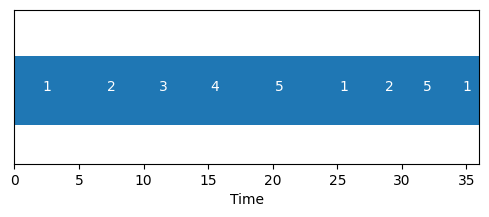

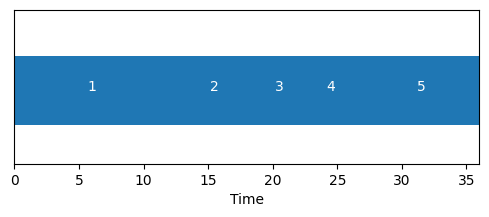

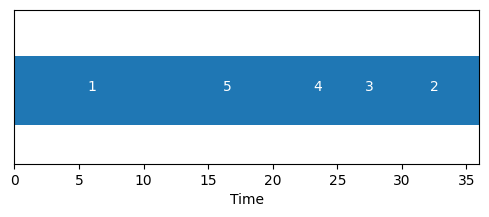

In [1]:
import tkinter as tk
from tkinter import ttk, messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt


class JobSchedulerApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Job Scheduler Calculator")
        self.process_data = []
        self.algorithms = {
            "FCFS": self.fcfs,
            "SJF": self.sjf,
            "SRTF": self.srtf,
            "RR": self.round_robin,
            "Priority (Non-Preemptive)": self.priority_non_preemptive,
            "Priority (Preemptive)": self.priority_preemptive
        }

        # UI Elements
        self.create_ui()

    def create_ui(self):
        # Input Frame
        input_frame = tk.LabelFrame(self.root, text="Input Processes", padx=10, pady=10)
        input_frame.pack(fill="x", padx=10, pady=5)

        tk.Label(input_frame, text="Process Name").grid(row=0, column=0, padx=5, pady=5)
        tk.Label(input_frame, text="Arrival Time").grid(row=0, column=1, padx=5, pady=5)
        tk.Label(input_frame, text="Burst Time").grid(row=0, column=2, padx=5, pady=5)
        tk.Label(input_frame, text="Priority (Optional)").grid(row=0, column=3, padx=5, pady=5)

        self.entries = []
        for i in range(5):  # Default: 5 processes
            row = []
            for j in range(4):  # 4 fields: name, arrival, burst, priority
                entry = tk.Entry(input_frame, width=10)
                entry.grid(row=i + 1, column=j, padx=5, pady=5)
                row.append(entry)
            self.entries.append(row)

        # Algorithm Selection
        self.algorithm = tk.StringVar(value="FCFS")
        algorithms = list(self.algorithms.keys())
        tk.Label(self.root, text="Select Scheduling Algorithm:").pack(pady=5)
        algo_dropdown = ttk.Combobox(self.root, values=algorithms, textvariable=self.algorithm, state="readonly")
        algo_dropdown.pack(pady=5)

        # Quantum for RR
        self.quantum_label = tk.Label(self.root, text="Time Quantum (for RR):")
        self.quantum_label.pack(pady=5)
        self.quantum_entry = tk.Entry(self.root, width=10)
        self.quantum_entry.pack(pady=5)

        # Buttons
        btn_frame = tk.Frame(self.root)
        btn_frame.pack(pady=10)
        tk.Button(btn_frame, text="Calculate", command=self.calculate_schedule).grid(row=0, column=0, padx=5)
        tk.Button(btn_frame, text="Clear", command=self.clear_inputs).grid(row=0, column=1, padx=5)

        # Output Section
        self.output_frame = tk.LabelFrame(self.root, text="Output", padx=10, pady=10)
        self.output_frame.pack(fill="both", expand=True, padx=10, pady=5)

    def clear_inputs(self):
        for row in self.entries:
            for entry in row:
                entry.delete(0, tk.END)
        self.process_data.clear()
        for widget in self.output_frame.winfo_children():
            widget.destroy()

    def calculate_schedule(self):
        try:
            self.process_data = []
            for row in self.entries:
                name = row[0].get()
                if not name:
                    continue
                arrival_time = int(row[1].get())
                burst_time = int(row[2].get())
                priority = int(row[3].get()) if row[3].get() else None
                self.process_data.append({
                    "name": name,
                    "arrival_time": arrival_time,
                    "burst_time": burst_time,
                    "priority": priority,
                })

            if not self.process_data:
                messagebox.showerror("Error", "No valid process data entered.")
                return

            algorithm = self.algorithm.get()
            if algorithm == "RR":
                quantum = int(self.quantum_entry.get())
                if quantum <= 0:
                    raise ValueError("Quantum must be a positive integer.")
                result = self.algorithms[algorithm](self.process_data, quantum)
            else:
                result = self.algorithms[algorithm](self.process_data)

            self.display_results(result)

        except ValueError as e:
            messagebox.showerror("Input Error", str(e))

    def fcfs(self, processes):
        processes.sort(key=lambda x: x["arrival_time"])
        time = 0
        gantt_chart = []
        waiting_times = []
        turnaround_times = []

        for process in processes:
            if time < process["arrival_time"]:
                time = process["arrival_time"]
            start_time = time
            gantt_chart.append((process["name"], start_time, start_time + process["burst_time"]))
            time += process["burst_time"]
            waiting_times.append(start_time - process["arrival_time"])
            turnaround_times.append(time - process["arrival_time"])

        return {"gantt_chart": gantt_chart, "metrics": self.calculate_metrics(waiting_times, turnaround_times)}

    def sjf(self, processes):
        processes.sort(key=lambda x: (x["arrival_time"], x["burst_time"]))
        time = 0
        gantt_chart = []
        waiting_times = []
        turnaround_times = []

        while processes:
            available_processes = [p for p in processes if p["arrival_time"] <= time]
            if not available_processes:
                time += 1
                continue

            next_process = min(available_processes, key=lambda x: x["burst_time"])
            processes.remove(next_process)

            start_time = time
            gantt_chart.append((next_process["name"], start_time, start_time + next_process["burst_time"]))
            time += next_process["burst_time"]
            waiting_times.append(start_time - next_process["arrival_time"])
            turnaround_times.append(time - next_process["arrival_time"])

        return {"gantt_chart": gantt_chart, "metrics": self.calculate_metrics(waiting_times, turnaround_times)}

    def srtf(self, processes):
        time = 0
        gantt_chart = []
        waiting_times = []
        turnaround_times = []
        remaining_processes = processes[:]
        process_queue = []

        while remaining_processes or process_queue:
            process_queue = [p for p in remaining_processes if p["arrival_time"] <= time]
            if not process_queue:
                time += 1
                continue

            current_process = min(process_queue, key=lambda x: x["burst_time"])
            remaining_processes.remove(current_process)

            start_time = time
            gantt_chart.append((current_process["name"], start_time, start_time + current_process["burst_time"]))
            time += current_process["burst_time"]
            waiting_times.append(start_time - current_process["arrival_time"])
            turnaround_times.append(time - current_process["arrival_time"])

        return {"gantt_chart": gantt_chart, "metrics": self.calculate_metrics(waiting_times, turnaround_times)}

    def round_robin(self, processes, quantum):
        time = 0
        gantt_chart = []
        waiting_times = []
        turnaround_times = []
        process_queue = processes[:]

        while process_queue:
            process = process_queue.pop(0)
            burst_time = process["burst_time"]
            executed_time = min(quantum, burst_time)

            start_time = time
            gantt_chart.append((process["name"], start_time, start_time + executed_time))
            time += executed_time
            process["burst_time"] -= executed_time

            if process["burst_time"] > 0:
                process_queue.append(process)
            else:
                waiting_times.append(start_time - process["arrival_time"])
                turnaround_times.append(time - process["arrival_time"])

        return {"gantt_chart": gantt_chart, "metrics": self.calculate_metrics(waiting_times, turnaround_times)}

    def priority_non_preemptive(self, processes):
        processes.sort(key=lambda x: (x["arrival_time"], -x["priority"]))
        time = 0
        gantt_chart = []
        waiting_times = []
        turnaround_times = []

        for process in processes:
            if time < process["arrival_time"]:
                time = process["arrival_time"]
            start_time = time
            gantt_chart.append((process["name"], start_time, start_time + process["burst_time"]))
            time += process["burst_time"]
            waiting_times.append(start_time - process["arrival_time"])
            turnaround_times.append(time - process["arrival_time"])

        return {"gantt_chart": gantt_chart, "metrics": self.calculate_metrics(waiting_times, turnaround_times)}

    def priority_preemptive(self, processes):
        time = 0
        gantt_chart = []
        waiting_times = []
        turnaround_times = []
        remaining_processes = processes[:]
        process_queue = []

        while remaining_processes or process_queue:
            process_queue = [p for p in remaining_processes if p["arrival_time"] <= time]
            if not process_queue:
                time += 1
                continue

            current_process = min(process_queue, key=lambda x: -x["priority"])
            remaining_processes.remove(current_process)

            start_time = time
            gantt_chart.append((current_process["name"], start_time, start_time + current_process["burst_time"]))
            time += current_process["burst_time"]
            waiting_times.append(start_time - current_process["arrival_time"])
            turnaround_times.append(time - current_process["arrival_time"])

        return {"gantt_chart": gantt_chart, "metrics": self.calculate_metrics(waiting_times, turnaround_times)}

    def calculate_metrics(self, waiting_times, turnaround_times):
        avg_waiting_time = sum(waiting_times) / len(waiting_times)
        avg_turnaround_time = sum(turnaround_times) / len(turnaround_times)
        return {"waiting_time": waiting_times, "turnaround_time": turnaround_times,
                "avg_waiting_time": avg_waiting_time, "avg_turnaround_time": avg_turnaround_time}

    def display_results(self, result):
        for widget in self.output_frame.winfo_children():
            widget.destroy()

        tk.Label(self.output_frame, text="Gantt Chart:").pack()
        self.display_gantt_chart(result["gantt_chart"])

        metrics = result["metrics"]
        metrics_text = f"Avg Waiting Time: {metrics['avg_waiting_time']:.2f}\nAvg Turnaround Time: {metrics['avg_turnaround_time']:.2f}"
        tk.Label(self.output_frame, text=metrics_text, justify="left").pack()

    def display_gantt_chart(self, gantt_chart):
        fig, ax = plt.subplots(figsize=(6, 2))
        for process, start, end in gantt_chart:
            ax.broken_barh([(start, end - start)], (10, 9), facecolors='tab:blue')
            ax.text(start + (end - start) / 2, 15, process, ha='center', va='center', color='white')
        ax.set_ylim(5, 25)
        ax.set_xlim(0, sum(end - start for _, start, end in gantt_chart))
        ax.set_xlabel('Time')
        ax.set_yticks([])
        canvas = FigureCanvasTkAgg(fig, self.output_frame)
        canvas.get_tk_widget().pack()
        canvas.draw()


if __name__ == "__main__":
    root = tk.Tk()
    app = JobSchedulerApp(root)
    root.mainloop()
